# Data Cleansing

## Import Library

In [80]:
import pandas as pd

## Membaca Data

In [81]:
df = pd.read_csv("data/heart_statlog.csv")
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


## Melihat Nama Kolom yang Ada

In [82]:
# melihat jumlah kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


## Check Missing Values

In [83]:
# melihat di setiap kolom apakah ada data yang hilanhg atau tidak
df.isna().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

## Cek Outliers

In [84]:
for col in df.columns:
    print(f"running for {col}")
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    fence_high = q3 + 1.5 * iqr
    fence_low = q1 - 1.5 * iqr
    
    outliers = df[(df[col] < fence_low) | (df[col] > fence_high)]
    print(outliers.shape)

running for age
(0, 12)
running for sex
(281, 12)
running for chest pain type
(66, 12)
running for resting bp s
(37, 12)
running for cholesterol
(193, 12)
running for fasting blood sugar
(254, 12)
running for resting ecg
(0, 12)
running for max heart rate
(1, 12)
running for exercise angina
(0, 12)
running for oldpeak
(11, 12)
running for ST slope
(0, 12)
running for target
(0, 12)


## Penghapusan Data Outliers

In [85]:
for col in df.columns:
    print(f"running for {col}")
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    fence_high = q3 + 1.5 * iqr
    fence_low = q1 - 1.5 * iqr
    
    outliers = df[(df[col] < fence_low) | (df[col] > fence_high)]
    df = df[(df[col] >= fence_low) & (df[col] <= fence_high) ]

running for age
running for sex
running for chest pain type
running for resting bp s
running for cholesterol
running for fasting blood sugar
running for resting ecg
running for max heart rate
running for exercise angina
running for oldpeak
running for ST slope
running for target


In [86]:
df.shape

(562, 12)

In [87]:
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
2,37,1,2,130,283,0,1,98,0,0.0,1,0
4,54,1,3,150,195,0,0,122,0,0.0,1,0
5,39,1,3,120,339,0,0,170,0,0.0,1,0
7,54,1,2,110,208,0,0,142,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1179,44,1,4,120,169,0,0,144,1,2.8,3,1
1180,63,1,4,140,187,0,2,144,1,4.0,1,1
1182,41,1,2,120,157,0,0,182,0,0.0,1,0
1187,57,1,4,130,131,0,0,115,1,1.2,2,1


## Cek Duplikasi Data

In [88]:
df.duplicated().sum()

np.int64(141)

# EDA (Exploratory Data Analysis)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  562 non-null    int64  
 1   sex                  562 non-null    int64  
 2   chest pain type      562 non-null    int64  
 3   resting bp s         562 non-null    int64  
 4   cholesterol          562 non-null    int64  
 5   fasting blood sugar  562 non-null    int64  
 6   resting ecg          562 non-null    int64  
 7   max heart rate       562 non-null    int64  
 8   exercise angina      562 non-null    int64  
 9   oldpeak              562 non-null    float64
 10  ST slope             562 non-null    int64  
 11  target               562 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 57.1 KB


## Univariate Analysis (Analisis Masing-Masing Variable)

In [90]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,562.000000,562.0,562.000000,562.000000,562.000000,562.0,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000
mean,52.373665,1.0,3.366548,130.190391,239.256228,0.0,0.676157,140.514235,0.425267,0.981851,1.580071,0.544484
std,9.448569,0.0,0.801615,14.959638,48.276741,0.0,0.886682,24.924856,0.494824,1.098496,0.592431,0.498461
min,28.000000,1.0,2.000000,92.000000,85.000000,0.0,0.000000,71.000000,0.000000,-0.100000,1.000000,0.000000
25%,45.000000,1.0,3.000000,120.000000,207.250000,0.0,0.000000,122.000000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,1.0,4.000000,130.000000,235.000000,0.0,0.000000,140.000000,0.000000,0.600000,2.000000,1.000000
75%,59.000000,1.0,4.000000,140.000000,271.750000,0.0,2.000000,160.000000,1.000000,1.800000,2.000000,1.000000
max,77.000000,1.0,4.000000,170.000000,388.000000,0.0,2.000000,202.000000,1.000000,4.400000,3.000000,1.000000


## Plot Histogram

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

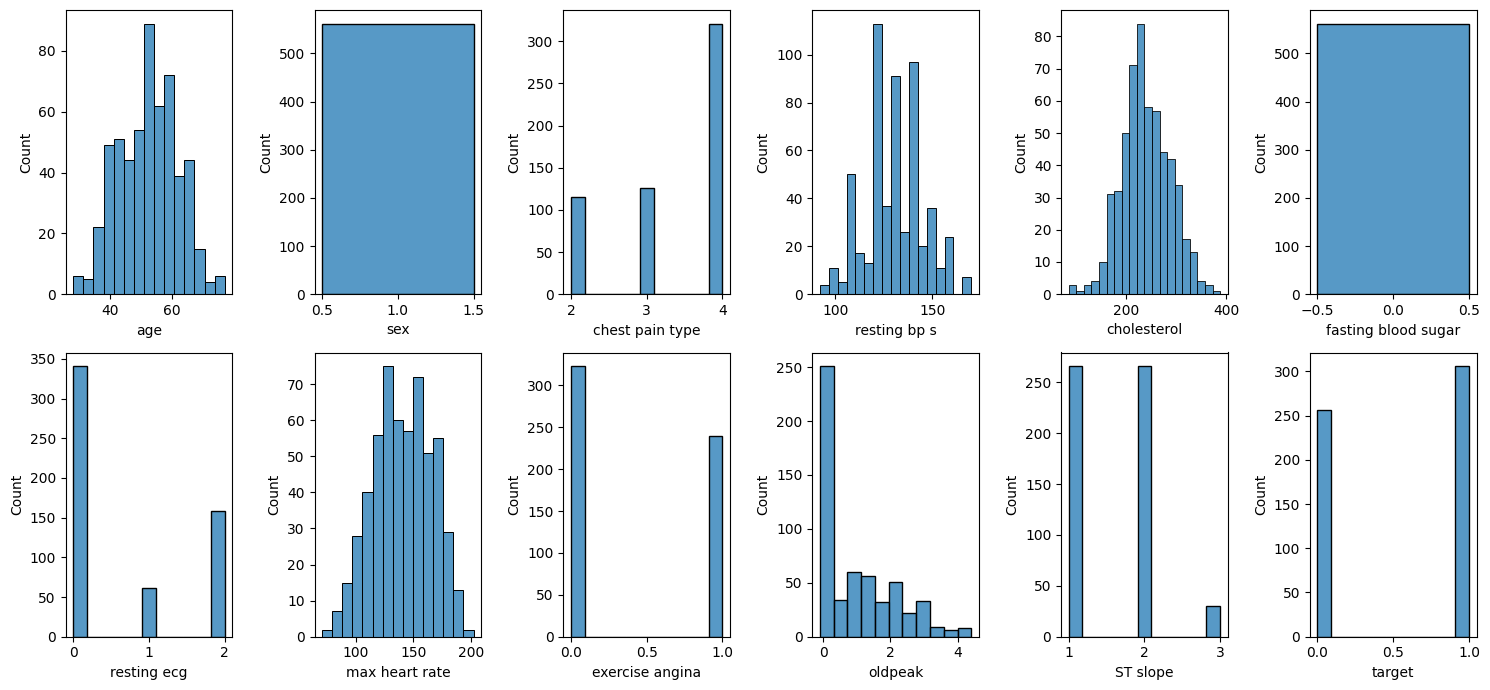

In [92]:
plt.figure(figsize = (15, 7))

for i in range(len(df.columns)):
    plt.subplot(2, 6, i+1)
    sns.histplot(x = df.columns[i], data = df)
    plt.tight_layout()

## Multivariate Analysis

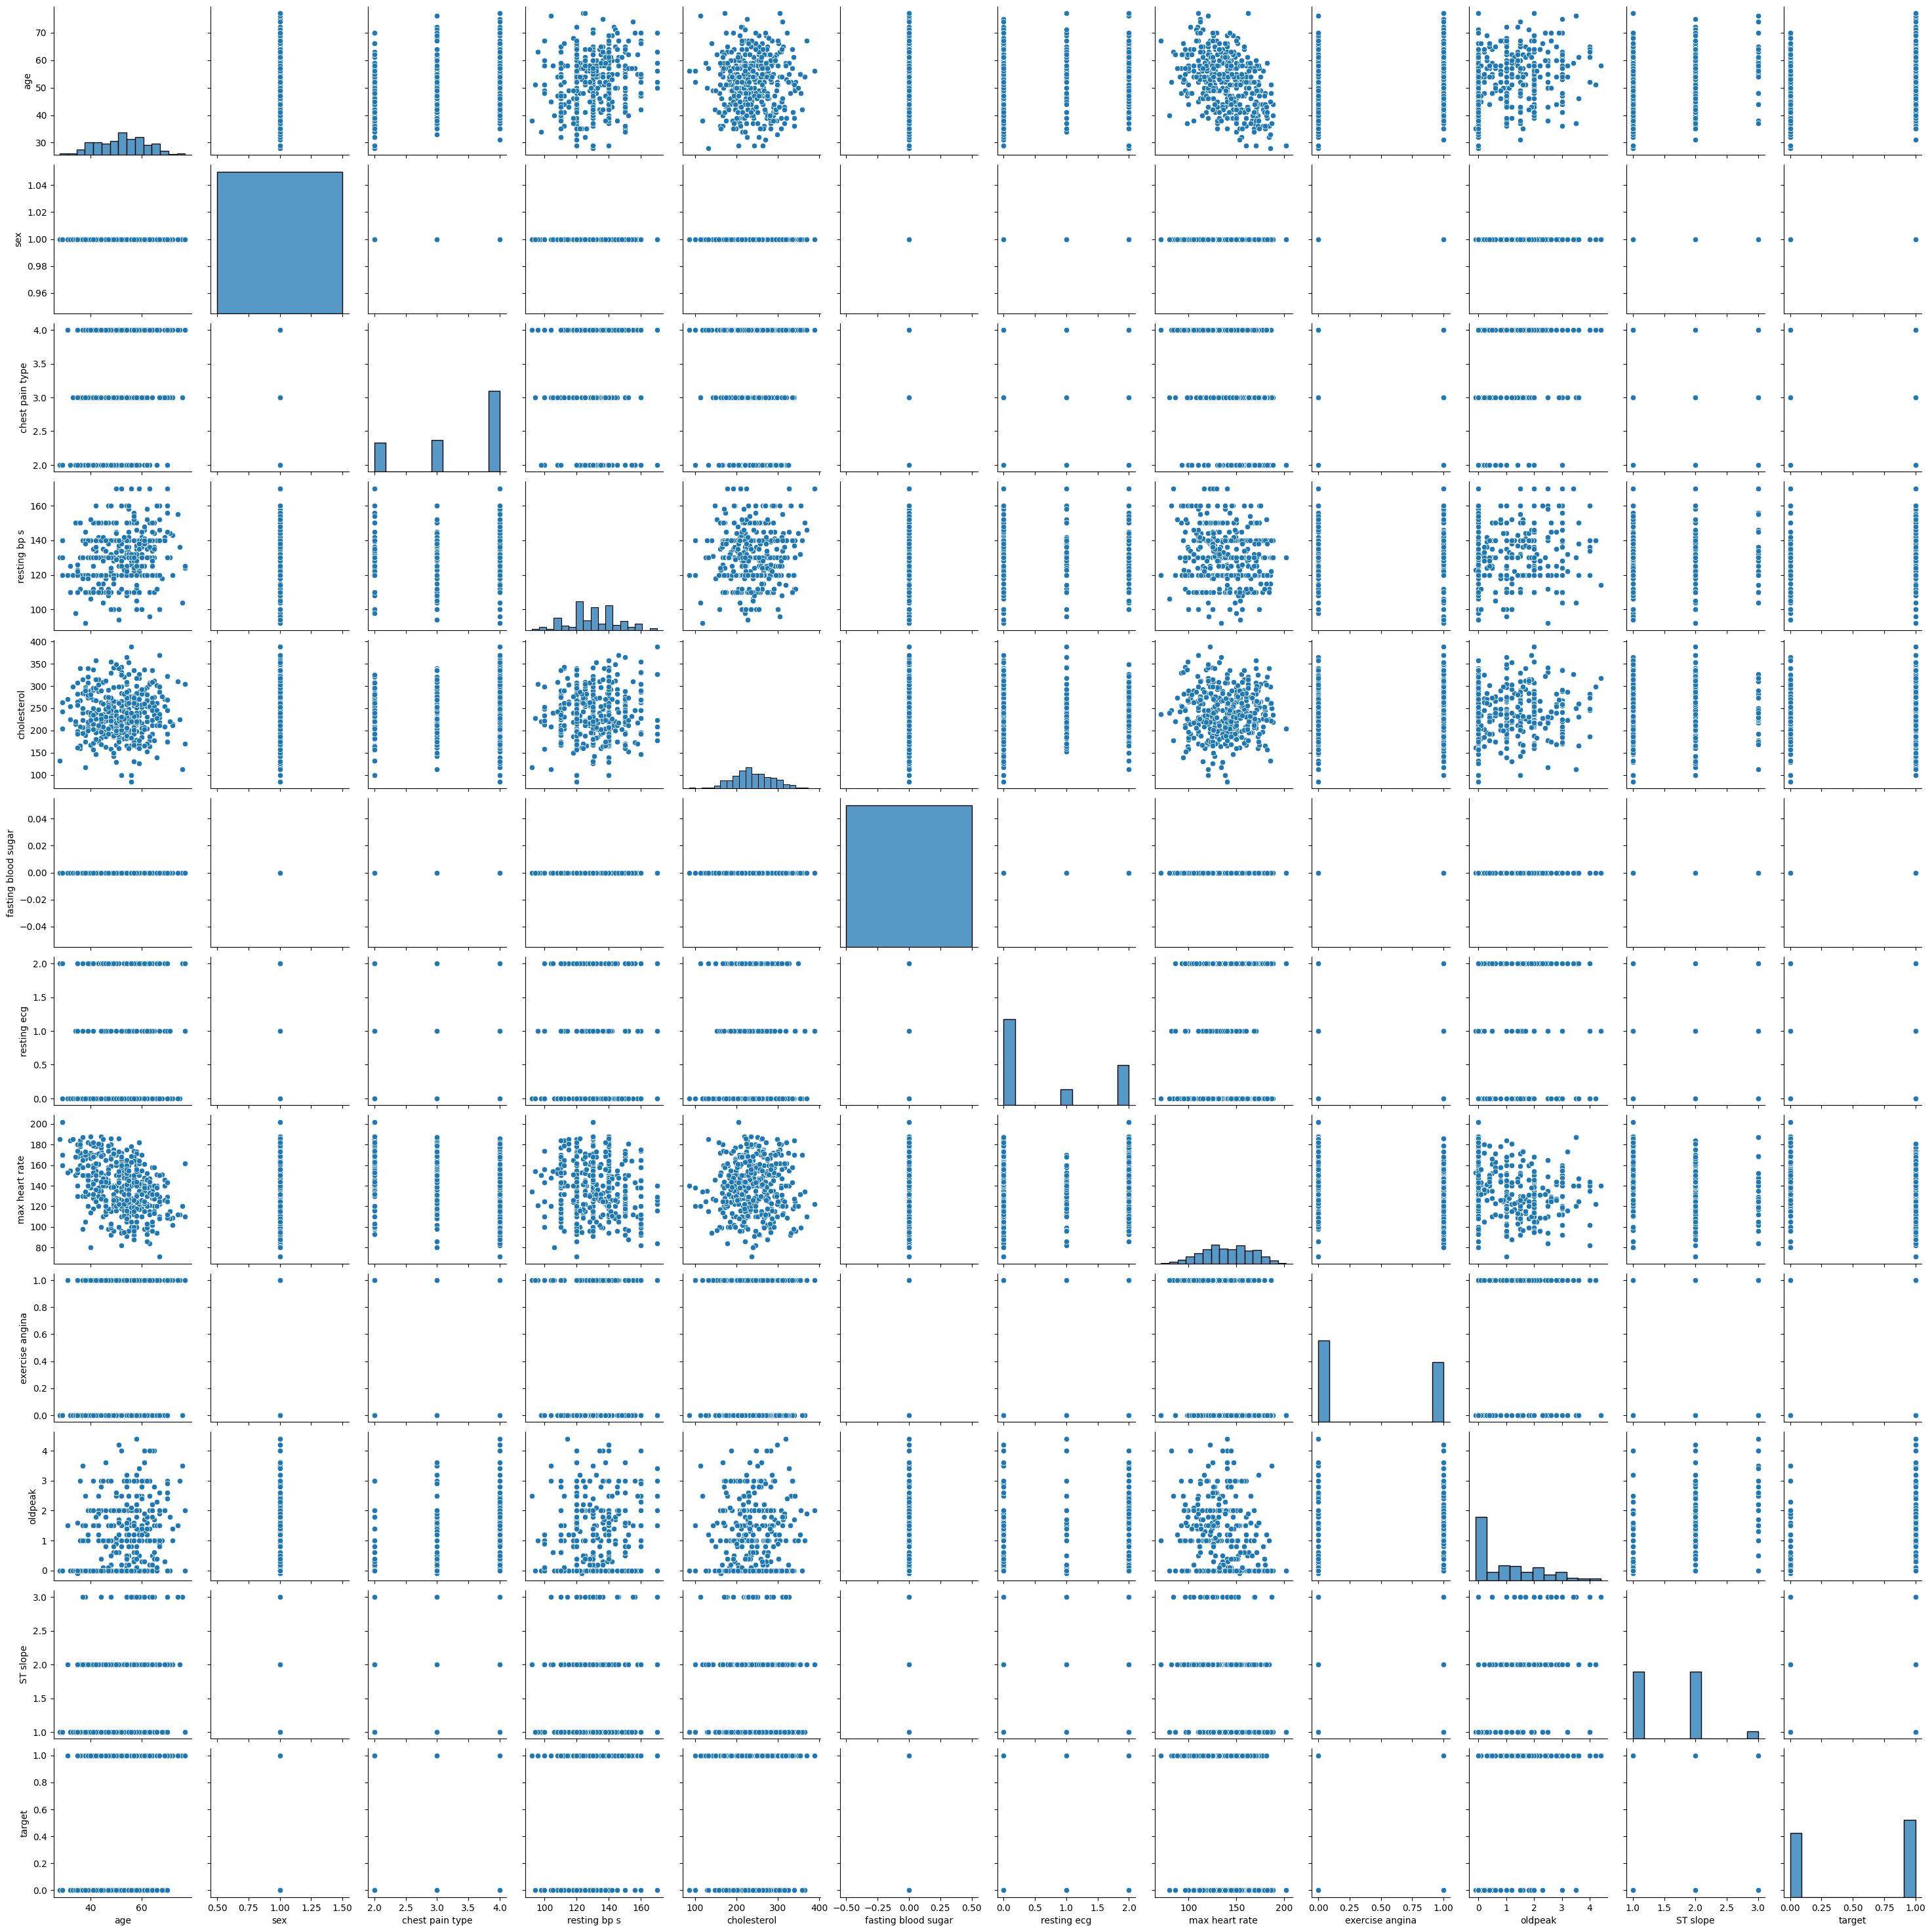

In [93]:
sns.pairplot(df)

<Axes: >

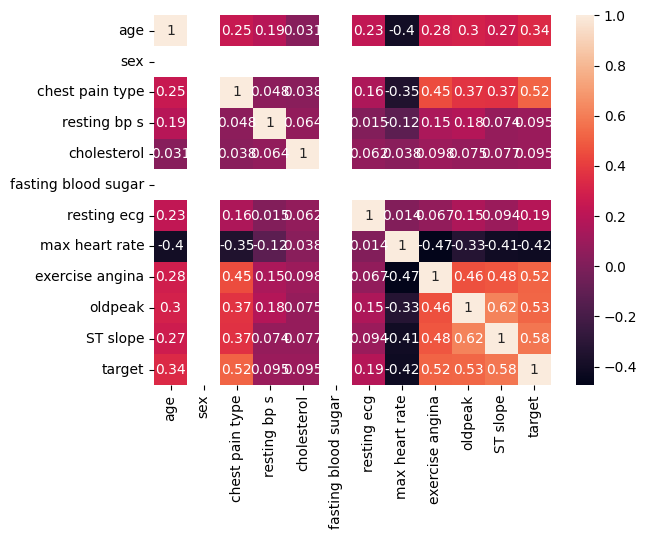

In [94]:
sns.heatmap(df.corr(), annot=True)

# Additional Data Preparation before Modeling

## Feature Engineering

In [95]:
df["max_heart_rate_per_age"] = df["max heart rate"] / df["age"]
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,max_heart_rate_per_age
0,40,1,2,140,289,0,0,172,0,0.0,1,0,4.300000
2,37,1,2,130,283,0,1,98,0,0.0,1,0,2.648649
4,54,1,3,150,195,0,0,122,0,0.0,1,0,2.259259
5,39,1,3,120,339,0,0,170,0,0.0,1,0,4.358974
7,54,1,2,110,208,0,0,142,0,0.0,1,0,2.629630
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,44,1,4,120,169,0,0,144,1,2.8,3,1,3.272727
1180,63,1,4,140,187,0,2,144,1,4.0,1,1,2.285714
1182,41,1,2,120,157,0,0,182,0,0.0,1,0,4.439024
1187,57,1,4,130,131,0,0,115,1,1.2,2,1,2.017544


## Train Test Split

In [96]:
from sklearn.model_selection import train_test_split

In [97]:
x = df.drop(columns = ["target"])
y = df["target"]

In [98]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

In [99]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(449, 12)
(113, 12)
(449,)
(113,)


# Modeling (Classification Model) & Evaluation

## menggunakan algoritma Decision Tree

In [100]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(x_train, y_train)

DecisionTreeClassifier()

## menggunakan algoritma Random Forest (tanpa hyperparameter tuning)

In [101]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

## menggunakan algoritma Random Forest (dengan hyperparameter tuning)

In [102]:
params = {
	"max_depth": [2, 3, 4, 5, 10, 15],
	"min_samples_leaf": [10, 15, 20, 50, 100]
}

In [103]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator = RandomForestClassifier(),
                           param_grid = params,
                           cv = 5,
                           scoring = "roc_auc")
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 3, 4, 5, 10, 15],
                         'min_samples_leaf': [10, 15, 20, 50, 100]},
             scoring='roc_auc')

In [104]:
rf_best = grid_search.best_estimator_
rf_best.fit(x_train, y_train)

RandomForestClassifier(max_depth=4, min_samples_leaf=10)

## Evaluasi (membandingkan 3 algoritma)

## Recall Score

In [105]:
from sklearn.metrics import recall_score

y_dtree = dtree.predict(x_test)
y_rf = rf.predict(x_test)
y_rf_best = rf_best.predict(x_test)

In [106]:
print(recall_score(y_test, y_dtree, pos_label = 1, average = "binary"))
print(recall_score(y_test, y_rf, pos_label = 1, average = "binary"))
print(recall_score(y_test, y_rf_best, pos_label = 1, average = "binary"))

0.9230769230769231
0.9384615384615385
0.8153846153846154


# Precision Score

In [107]:
from sklearn.metrics import precision_score

print(precision_score(y_test, y_dtree, pos_label = 1, average = "binary"))
print(precision_score(y_test, y_rf, pos_label = 1, average = "binary"))
print(precision_score(y_test, y_rf_best, pos_label = 1, average = "binary"))

0.8695652173913043
0.9242424242424242
0.8412698412698413


## F1-Score

In [108]:
from sklearn.metrics import f1_score

print(f1_score(y_test, y_dtree, pos_label=1, average="binary"))
print(f1_score(y_test, y_rf, pos_label=1, average="binary"))
print(f1_score(y_test, y_rf_best, pos_label=1, average="binary"))

0.8955223880597015
0.9312977099236641
0.828125


## ROC-AUC Score

In [109]:
from sklearn.metrics import roc_auc_score

y_prob_dtree = dtree.predict_proba(x_test) [:, 1]
y_prob_rf = rf.predict_proba(x_test) [:, 1]
y_prob_rf_best = rf_best.predict_proba(x_test) [:, 1]

In [110]:
print(roc_auc_score(y_test, y_prob_dtree))
print(roc_auc_score(y_test, y_prob_rf))
print(roc_auc_score(y_test, y_prob_rf_best))

0.8677884615384616
0.9725961538461538
0.9006410256410257


# Evaluasi (hanya menggunakan Random Forest)

In [111]:
y_rf = rf.predict(x_test)

## Recall Score

In [112]:
print(recall_score(y_test, y_rf, pos_label = 1, average = "binary"))

0.9384615384615385


## Precision Score

In [113]:
print(precision_score(y_test, y_rf, pos_label = 1, average = "binary"))

0.9242424242424242


## F1-Score

In [114]:
print(f1_score(y_test, y_rf, pos_label=1, average="binary"))

0.9312977099236641


## ROC-AUC Score

In [115]:
print(roc_auc_score(y_test, y_prob_rf))

0.9725961538461538
